### 3.1 Fazendo experimentos com modelo de regressão

_os experimentos a seguir que deram ainda mais força para o projeto se tornar baseado em classificação, ao decorrer desse notebook fica visível (com dados reais) o motivo dessa afirmação_

In [2]:
# IMPORTANDO PANDAS E MATPLOTLIB
import pandas as pd
import numpy as np

In [3]:
# CRIANDO UM DATAFRAME A PARTIR DOS DADOS
from data_loading import load_data
from preprocessing import prepare_data

df = load_data('../data/raw/state_of_data_survey_2024.csv')
df = prepare_data(df)


In [10]:
# DEFININDO E PREPARANDO O VALOR TARGET (SALÁRIOS)

# TRADUZIR: #FINDING THE FEATURE TO TARGET
list(df.columns)
df['2.h_faixa_salarial'].value_counts().sort_values()

novas_categorias = {
    'de R$ 8.001/mês a R$ 12.000/mês': 'de R$ 8.001/mês a R$ 12.000/mês',
    'de R$ 12.001/mês a R$ 16.000/mês': 'de R$ 12.001/mês a R$ 20.000/mês',
    'de R$ 6.001/mês a R$ 8.000/mês': 'de R$ 6.001/mês a R$ 8.000/mês',
    'de R$ 4.001/mês a R$ 6.000/mês': 'de 3.001/mês a R$ 6.000/mês',
    'de R$ 16.001/mês a R$ 20.000/mês': 'de R$ 12.001/mês a R$ 20.000/mês',
    'de R$ 3.001/mês a R$ 4.000/mês': 'de 3.001/mês a R$ 6.000/mês',
    'de R$ 20.001/mês a R$ 25.000/mês': 'acima de R$ 20.000/mês',
    'de R$ 2.001/mês a R$ 3.000/mês': 'até R$ 3.000/mês',
    'de R$ 25.001/mês a R$ 30.000/mês': 'acima de R$ 20.000/mês',
    'de R$ 30.001/mês a R$ 40.000/mês': 'acima de R$ 20.000/mês',
    'de R$ 1.001/mês a R$ 2.000/mês': 'até R$ 3.000/mês',
    'Acima de R$ 40.001/mês': 'acima de R$ 20.000/mês',
    'Menos de R$ 1.000/mês': 'até R$ 3.000/mês'
}

df['categorias_target'] = df['2.h_faixa_salarial'].map(novas_categorias)
df = df[df['categorias_target'].isna() == False]





In [ ]:
df['categorias_target'].isna().sum()

np.int64(0)

<Axes: >

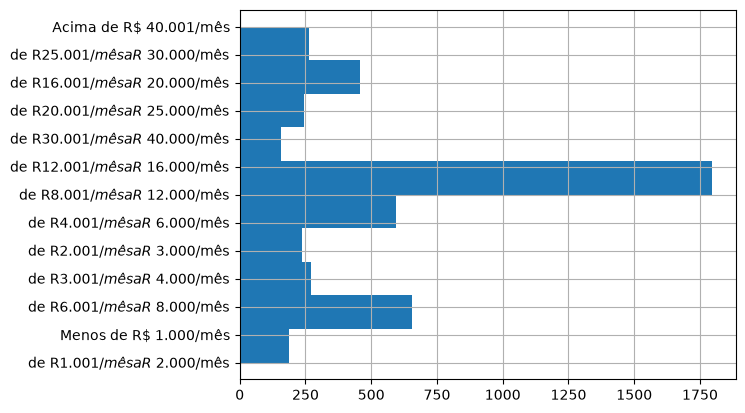

In [ ]:
# ANALISANDO O GRÁFICO

df['2.h_faixa_salarial'].hist(orientation='horizontal',
                              histtype='bar')

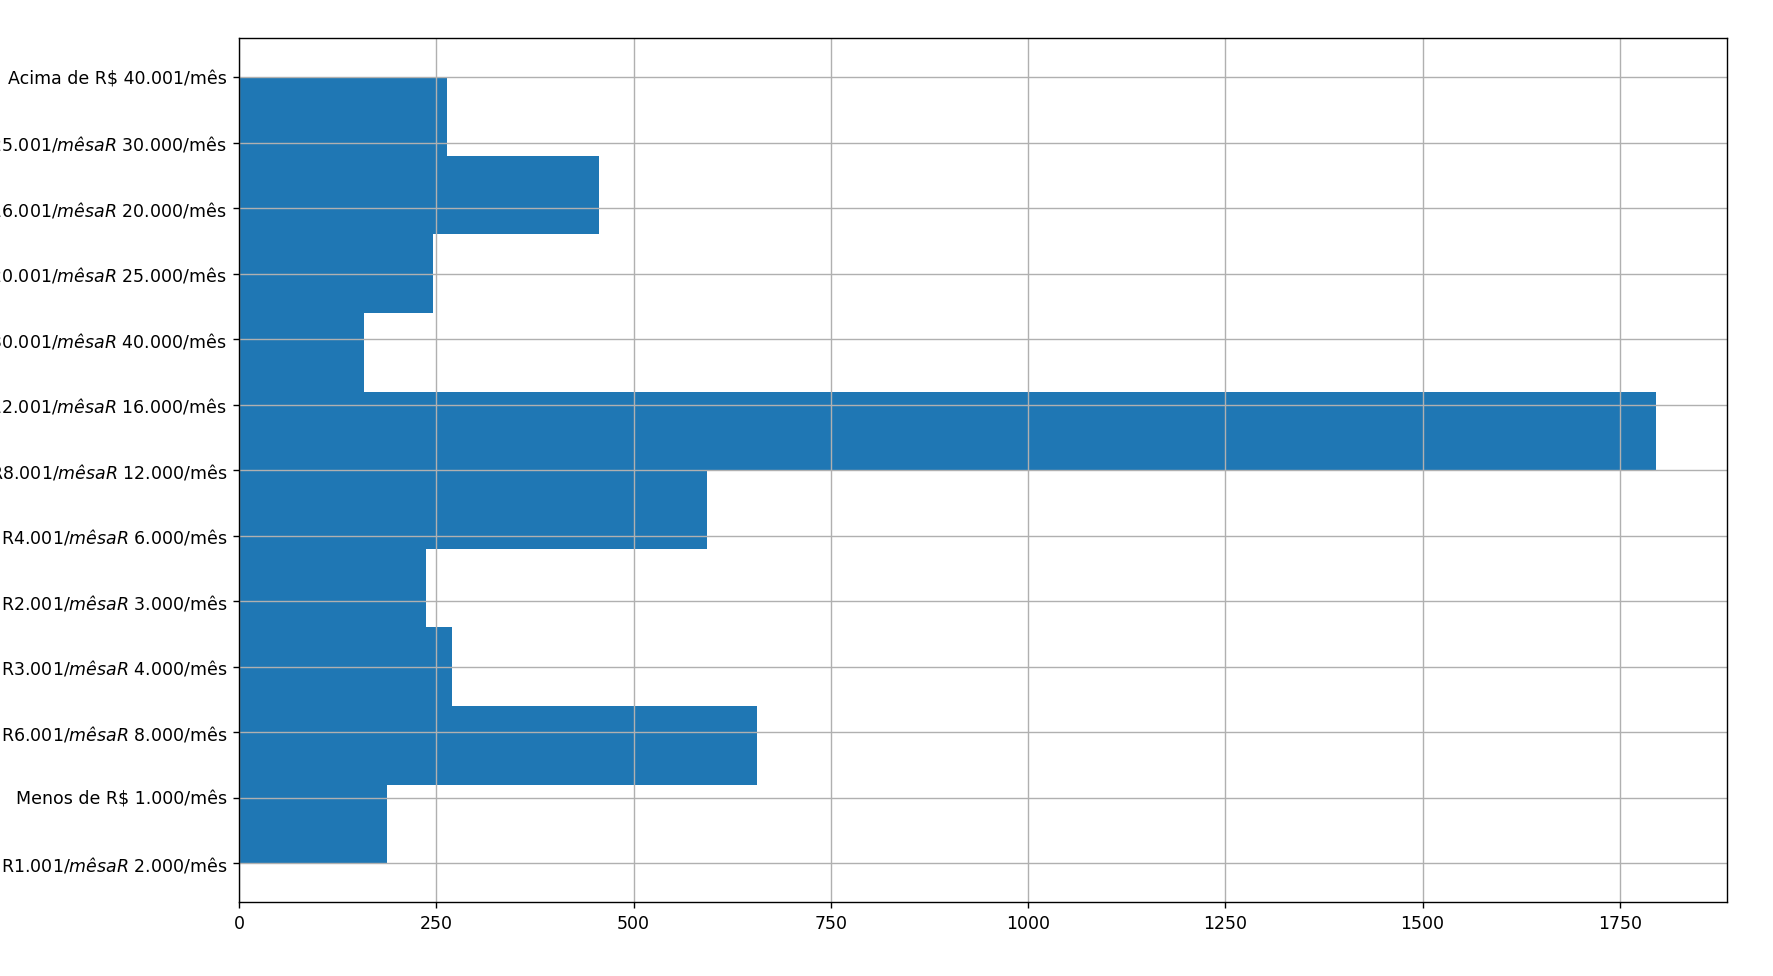

### 3.2. Transformando o dado categórico para númerico discretizado

Quero construir um modelo de regressão (que prevê um valor numérico), então prefiro usar o valor médio de cada categoria.

In [ ]:
categoria_para_valor = {
    'de R$ 8.001/mês a R$ 12.000/mês': 10000,
    'de R$ 12.001/mês a R$ 16.000/mês': 14000,
    'de R$ 6.001/mês a R$ 8.000/mês': 7000,
    'de R$ 4.001/mês a R$ 6.000/mês': 5000,
    'de R$ 16.001/mês a R$ 20.000/mês': 18000,
    'de R$ 3.001/mês a R$ 4.000/mês': 3500,
    'de R$ 20.001/mês a R$ 25.000/mês': 22500,
    'de R$ 2.001/mês a R$ 3.000/mês': 2500,
    'de R$ 25.001/mês a R$ 30.000/mês': 27500,
    'de R$ 30.001/mês a R$ 40.000/mês': 35000,
    'de R$ 1.001/mês a R$ 2.000/mês': 1500,
    'Acima de R$ 40.001/mês': 40500,
    'Menos de R$ 1.000/mês': 500
}

df['salario_medio_por_faixas'] = df['2.h_faixa_salarial'].map(categoria_para_valor)

<Axes: xlabel='salario_medio_por_faixas'>

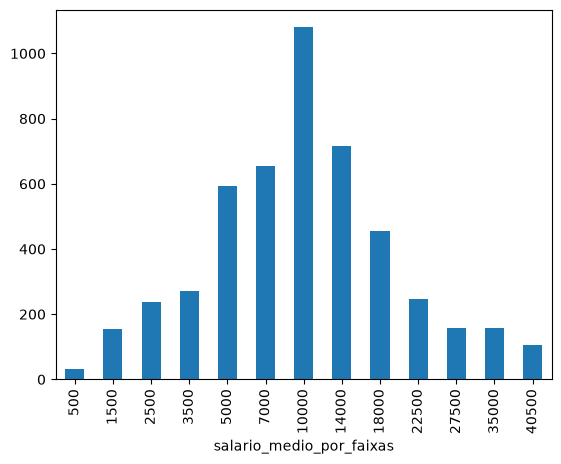

In [ ]:
df = df.dropna(subset=['salario_medio_por_faixas'])
df['salario_medio_por_faixas'].isna().sum()

# VERIFICANDO COMO FICA
df['salario_medio_por_faixas'].value_counts().sort_index().plot(kind='bar')

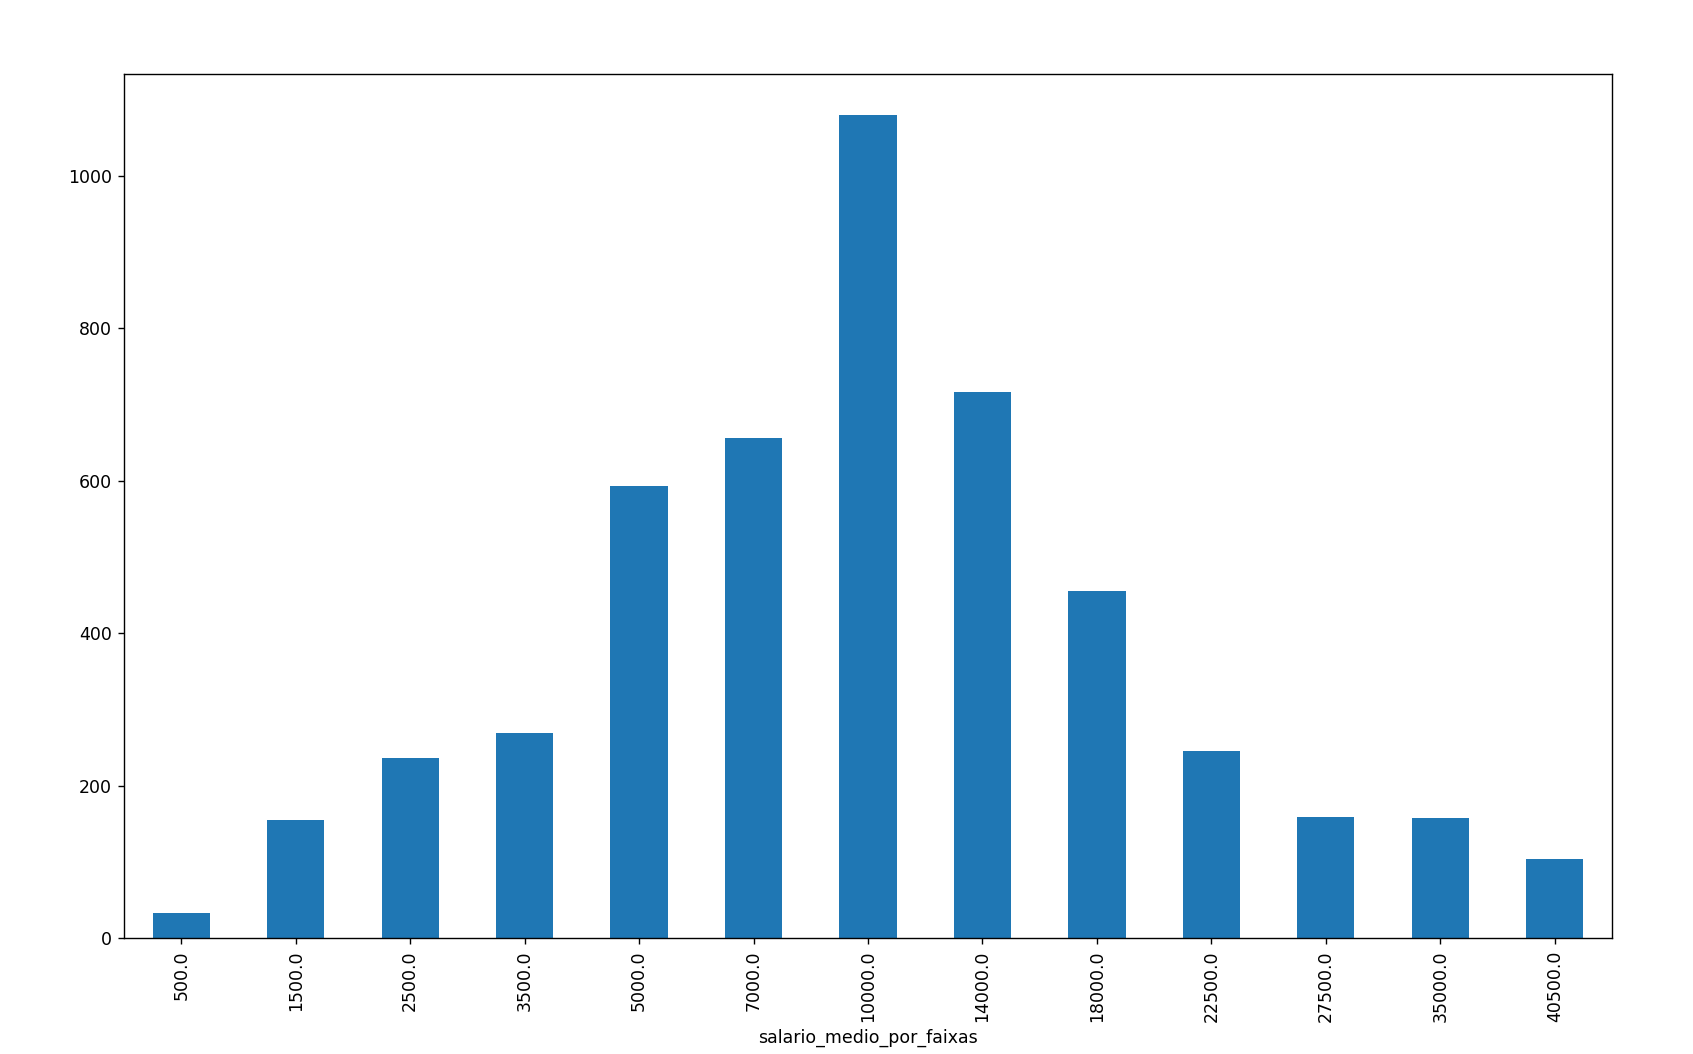

Removendo linhas com vive_em_brasil == False, pois quero centralizar essa pesquisa para pessoas que moram no território brasileiro e ao analisar a coluna '1.h_pais_onde_mora', percebi que os dados não iriam auxiliar no projeto. Além de que a mudança na forma de pagamento pode tornar o projeto tendencioso.

In [ ]:
df = df[df['1.g_vive_no_brasil']] # df['1.g_vive_no_brasil'] == True


<Axes: >

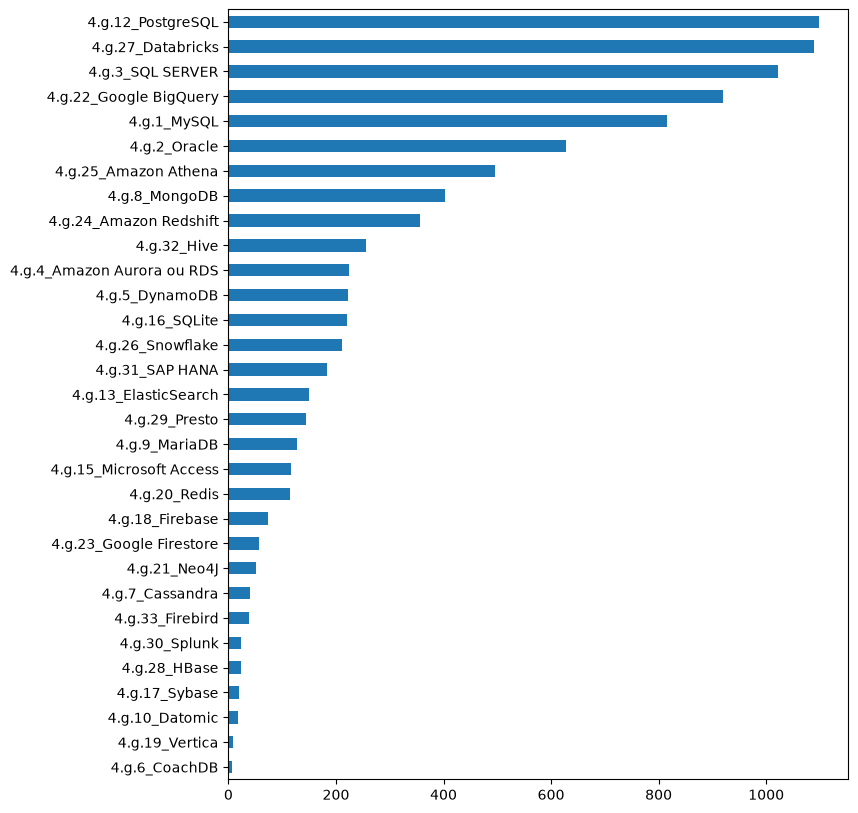

In [ ]:
teste_filtro_por_db = [ 
'4.g.1_MySQL',
'4.g.2_Oracle',
'4.g.3_SQL SERVER',
'4.g.4_Amazon Aurora ou RDS',
'4.g.5_DynamoDB',
'4.g.6_CoachDB',
'4.g.7_Cassandra',
'4.g.8_MongoDB',
'4.g.9_MariaDB',
'4.g.10_Datomic',
'4.g.12_PostgreSQL',
'4.g.13_ElasticSearch',
'4.g.15_Microsoft Access',
'4.g.16_SQLite',
'4.g.17_Sybase',
'4.g.18_Firebase',
'4.g.19_Vertica',
'4.g.20_Redis',
'4.g.21_Neo4J',
'4.g.22_Google BigQuery',
'4.g.23_Google Firestore',
'4.g.24_Amazon Redshift',
'4.g.25_Amazon Athena',
'4.g.26_Snowflake',
'4.g.27_Databricks',
'4.g.28_HBase',
'4.g.29_Presto',
'4.g.30_Splunk',
'4.g.31_SAP HANA',
'4.g.32_Hive',
'4.g.33_Firebird',

]

df[teste_filtro_por_db].sum().sort_values(ascending=True).plot(kind="barh", figsize=(8, 10))


### banco de dados escolhidos 

O gráfico mostra que 6 bancos concentram a maioria do uso, com queda acentuada depois de Oracle — o que motiva o corte em top-6.

- 4.g.2_Oracle                   627.0
- 4.g.1_MySQL                    816.0
- 4.g.22_Google BigQuery         920.0
- 4.g.3_SQL SERVER              1022.0
- 4.g.27_Databricks             1089.0
- 4.g.12_PostgreSQL             1098.0

In [ ]:
teste_filtro_por_cloud = [ 
'4.h.1_Amazon Web Services (AWS)',
'4.h.2_Google Cloud (GCP)',
'4.h.3_Azure (Microsoft)',
'4.h.4_Oracle Cloud',
'4.h.5_IBM',
'4.h.6_Servidores On Premise/Não utilizamos Cloud',
'4.h.7_Cloud Própria'
]

df[teste_filtro_por_cloud].sum().sort_values(ascending=True)


4.h.5_IBM                                             57.0
4.h.4_Oracle Cloud                                   138.0
4.h.7_Cloud Própria                                  185.0
4.h.6_Servidores On Premise/Não utilizamos Cloud     453.0
4.h.2_Google Cloud (GCP)                            1027.0
4.h.3_Azure (Microsoft)                             1073.0
4.h.1_Amazon Web Services (AWS)                     1549.0
dtype: float64

In [ ]:
df['2.g_nivel'].dropna()

0              Júnior
1              Júnior
2              Júnior
3              Júnior
4              Júnior
            ...      
5210           Sênior
5211    Nao Informado
5212    Nao Informado
5213           Sênior
5215    Nao Informado
Name: 2.g_nivel, Length: 4736, dtype: str

In [ ]:
df['2.j_tempo_de_experiencia_em_ti'].value_counts().sort_index()

2.j_tempo_de_experiencia_em_ti
Mais de 10 anos                                                                                             382
Menos de 1 ano                                                                                              445
Não tive experiência na área de TI/Engenharia de Software antes de começar a trabalhar na área de dados    2578
de 1 a 2 anos                                                                                               533
de 3 a 4 anos                                                                                               378
de 5 a 6 anos                                                                                               214
de 7 a 10 anos                                                                                              206
Name: count, dtype: int64

In [ ]:
selecionado = [
    '1.a_idade',
    '1.i.1_uf_onde_mora',
    '1.l_nivel_de_ensino', 
    '1.g_vive_no_brasil',
    '1.m_área_de_formação',
    '2.a_situação_de_trabalho',
    '2.b_setor',
    '2.f_cargo_atual',
    '2.g_nivel',   
    '2.j_tempo_de_experiencia_em_ti',
    '4.d.14_JavaScript',                                      
    '4.d.6_Java',
    '4.d.2_R',                                                
    '4.d.3_Python',                                          
    '4.d.1_SQL',
    '4.g.2_Oracle',           
    '4.g.1_MySQL',           
    '4.g.22_Google BigQuery', 
    '4.g.3_SQL SERVER',       
    '4.g.27_Databricks',      
    '4.g.12_PostgreSQL',
    '4.h.6_Servidores On Premise/Não utilizamos Cloud',
    '4.h.2_Google Cloud (GCP)',
    '4.h.3_Azure (Microsoft)',
    '4.h.1_Amazon Web Services (AWS)',
    'salario_medio_por_faixas'
]

df_tratado = (df[selecionado]
              .rename(columns={
                '1.a_idade': 'idade', 
                '1.d_pcd': 'pcd',
                '1.i.1_uf_onde_mora': 'uf_onde_mora',
                '1.l_nivel_de_ensino': 'nivel_de_ensino', 
                '1.g_vive_no_brasil' : 'vive_no_brasil',
                '1.m_área_de_formação': 'area_formacao',
                '2.a_situação_de_trabalho': 'situacao_trabalho',
                '2.b_setor': 'setor',
                '2.f_cargo_atual': 'cargo_atual',
                '2.g_nivel': 'nivel_senioridade',   
                '2.j_tempo_de_experiencia_em_ti': 'tempo_experiencia',
                '4.d.14_JavaScript': 'JS',                                      
                '4.d.6_Java': 'Java',
                '4.d.2_R': 'R',                                                
                '4.d.3_Python': 'Python',                                          
                '4.d.1_SQL': 'SQL',
                '4.g.2_Oracle': 'Oracle',           
                '4.g.1_MySQL': 'MySQL',           
                '4.g.22_Google BigQuery': 'Google_BigQuery', 
                '4.g.3_SQL SERVER': 'SQL_Server',       
                '4.g.27_Databricks': 'Databricks',      
                '4.g.12_PostgreSQL': 'PostgreSQL',
                '4.h.6_Servidores On Premise/Não utilizamos Cloud': 'nao_utilizamos_cloud',
                '4.h.2_Google Cloud (GCP)': 'Google_cloud',
                '4.h.3_Azure (Microsoft)': 'Azure',
                '4.h.1_Amazon Web Services (AWS)': 'AWS',
                'salario_medio_por_faixas':'salario_target'
                   
})) 

df_tratado

,idade,uf_onde_mora,nivel_de_ensino,vive_no_brasil,area_formacao,situacao_trabalho,setor,cargo_atual,nivel_senioridade,tempo_experiencia,...,MySQL,Google_BigQuery,SQL_Server,Databricks,PostgreSQL,nao_utilizamos_cloud,Google_cloud,Azure,AWS,salario_target
0,18,RS,Estudante de Graduação,True,Computação / Engenharia de Software / Sistemas...,Estagiário,Marketing,Analista de Dados/Data Analyst,Júnior,de 1 a 2 anos,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1500
1,18,SC,Estudante de Graduação,True,Computação / Engenharia de Software / Sistemas...,Estagiário,Finanças ou Bancos,Analista de BI/BI Analyst,Júnior,Menos de 1 ano,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,500
2,18,SP,Estudante de Graduação,True,Computação / Engenharia de Software / Sistemas...,Empregado (CLT),Indústria,Outra Opção,Júnior,Não tive experiência na área de TI/Engenharia ...,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1500
3,18,SP,Estudante de Graduação,True,Computação / Engenharia de Software / Sistemas...,Estagiário,Tecnologia/Fábrica de Software,Analista de Dados/Data Analyst,Júnior,Não tive experiência na área de TI/Engenharia ...,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1500
4,18,SP,Estudante de Graduação,True,Computação / Engenharia de Software / Sistemas...,Estagiário,Tecnologia/Fábrica de Software,Desenvolvedor/ Engenheiro de Software/ Analist...,Júnior,Menos de 1 ano,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5210,64,RJ,Pós-graduação,True,Outras Engenharias (não incluir engenharia de ...,Empregado (CLT),Setor de Energia,Engenheiro de Dados/Data Engineer/Data Architect,Sênior,de 7 a 10 anos,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,35000
5211,66,MG,Pós-graduação,True,Economia/ Administração / Contabilidade / Fina...,Empreendedor ou Empregado (CNPJ),Área da Saúde,Nao Informado,Nao Informado,de 1 a 2 anos,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14000
5212,66,RS,Graduação/Bacharelado,True,Computação / Engenharia de Software / Sistemas...,Empreendedor ou Empregado (CNPJ),Área de Consultoria,Nao Informado,Nao Informado,Mais de 10 anos,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22500
5213,66,DF,Mestrado,True,Computação / Engenharia de Software / Sistemas...,Empreendedor ou Empregado (CNPJ),Tecnologia/Fábrica de Software,Cientista de Dados/Data Scientist,Sênior,Mais de 10 anos,...,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,14000


## Dividindo os dados em train/test set

In [ ]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(df_tratado, 
                                       test_size=0.2, 
                                       stratify=df_tratado["salario_target"],
                                       random_state=42)



Gerando copia do train_set para analisar a correlação entre features e o target

In [ ]:
survey_data = train_set.copy()
survey_data


,idade,uf_onde_mora,nivel_de_ensino,vive_no_brasil,area_formacao,situacao_trabalho,setor,cargo_atual,nivel_senioridade,tempo_experiencia,...,MySQL,Google_BigQuery,SQL_Server,Databricks,PostgreSQL,nao_utilizamos_cloud,Google_cloud,Azure,AWS,salario_target
3919,36,SC,Mestrado,True,Outra opção,Prefiro não informar,Tecnologia/Fábrica de Software,Nao Informado,Nao Informado,Não tive experiência na área de TI/Engenharia ...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14000
2092,30,PR,Pós-graduação,True,Outras Engenharias (não incluir engenharia de ...,Empregado (CLT),Agronegócios,Analista de BI/BI Analyst,Pleno,Não tive experiência na área de TI/Engenharia ...,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5000
1699,28,DF,Pós-graduação,True,Outra opção,Empregado (CLT),Outra Opção,Engenheiro de Dados/Data Engineer/Data Architect,Pleno,Não tive experiência na área de TI/Engenharia ...,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,10000
2212,30,SP,Mestrado,True,Marketing / Publicidade / Comunicação / Jornal...,Estagiário,Setor Público,Outra Opção,Júnior,de 1 a 2 anos,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1500
5034,48,SP,Pós-graduação,True,Computação / Engenharia de Software / Sistemas...,Empreendedor ou Empregado (CNPJ),Tecnologia/Fábrica de Software,Nao Informado,Nao Informado,Mais de 10 anos,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2446,31,SP,Pós-graduação,True,Outras Engenharias (não incluir engenharia de ...,Empregado (CLT),Indústria,Cientista de Dados/Data Scientist,Sênior,Não tive experiência na área de TI/Engenharia ...,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,14000
2642,31,SP,Mestrado,True,Estatística/ Matemática / Matemática Computaci...,Empregado (CLT),Varejo,Nao Informado,Nao Informado,Não tive experiência na área de TI/Engenharia ...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18000
699,25,SP,Pós-graduação,True,Computação / Engenharia de Software / Sistemas...,Empregado (CLT),Tecnologia/Fábrica de Software,Engenheiro de Dados/Data Engineer/Data Architect,Pleno,de 1 a 2 anos,...,0.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,7000
1918,29,RJ,Graduação/Bacharelado,True,Computação / Engenharia de Software / Sistemas...,Empregado (CLT),Área de Consultoria,Engenheiro de Dados/Data Engineer/Data Architect,Pleno,Menos de 1 ano,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,10000


In [ ]:
correaltion = survey_data.corr(numeric_only=True)
correaltion['salario_target'].sort_values(ascending=False)

salario_target          1.000000
idade                   0.374409
AWS                     0.189461
Python                  0.164516
SQL                     0.133917
PostgreSQL              0.121843
Google_BigQuery         0.111027
Google_cloud            0.107816
Databricks              0.099042
Java                    0.091863
JS                      0.058642
MySQL                   0.025857
Oracle                  0.018501
R                      -0.001350
Azure                  -0.009582
SQL_Server             -0.011350
nao_utilizamos_cloud   -0.081498
vive_no_brasil               NaN
Name: salario_target, dtype: float64

In [ ]:
survey_data.groupby("nivel_senioridade")["salario_target"].median().sort_values()

nivel_senioridade
Júnior            3500.0
Pleno             7000.0
Sênior           14000.0
Nao Informado    18000.0
Name: salario_target, dtype: float64

In [ ]:
analysis_features = ["cargo_atual","situacao_trabalho","setor","uf_onde_mora",
                     "nivel_de_ensino","area_formacao",'tempo_experiencia']
for an in analysis_features:
    group = survey_data.groupby(an)["salario_target"].median().sort_values()
    print('MÉDIA SALARIAL POR: ', group)
    print('-' * 100)


MÉDIA SALARIAL POR:  cargo_atual
Outra Opção                                                     3500.0
Analista de BI/BI Analyst                                       5000.0
Analista de Suporte/Analista Técnico                            5000.0
Analista de Dados/Data Analyst                                  7000.0
Desenvolvedor/ Engenheiro de Software/ Analista de Sistemas     7000.0
Estatístico                                                     7000.0
Analista de Negócios/Business Analyst                           7000.0
Outras Engenharias (não inclui dev)                             8500.0
Professor/Pesquisador                                          10000.0
Data Product Manager/ Product Manager (PM/APM/DPM/GPM/PO)      10000.0
Cientista de Dados/Data Scientist                              10000.0
Analytics Engineer                                             10000.0
Engenheiro de Dados/Data Engineer/Data Architect               10000.0
Arquiteto de Dados/Data Architect           

Vou remover as categorias
- Desempregado e não estou buscando recolocação                         7
- Vivo fora do Brasil e trabalho para empresa de fora do Brasil         4

por serem pouco representativas e introduzir ruído no modelo desnecessáriamente, além disso pois removi anteriormente todas as linhas de pessoas que não moram no Brasil. Logo um ruído desnecessário foi adicionado ao projeto.

In [ ]:
remover = ['Vivo fora do Brasil e trabalho para empresa de fora do Brasil',
                          'Desempregado e não estou buscando recolocação']

survey_data = survey_data[~survey_data['situacao_trabalho'].isin(remover)]
# TRADUZIR: ~ introduz uma negação


In [ ]:
survey_data.isna().sum().sort_values(ascending=False)

Databricks              980
SQL_Server              980
Google_BigQuery         980
MySQL                   980
Oracle                  980
SQL                     980
Python                  980
R                       980
Java                    980
JS                      980
Google_cloud            980
Azure                   980
PostgreSQL              980
nao_utilizamos_cloud    980
AWS                     980
nivel_senioridade         0
tempo_experiencia         0
nivel_de_ensino           0
uf_onde_mora              0
idade                     0
cargo_atual               0
setor                     0
situacao_trabalho         0
area_formacao             0
vive_no_brasil            0
salario_target            0
dtype: int64

Analisando se todas as 980 são pessoas em comum

In [ ]:
python_bool = survey_data['Python'].isna()

amostragem = ['nivel_senioridade', 'cargo_atual', 'SQL', 'Python']

survey_data.loc[python_bool, amostragem].isna().all(axis=1).sum()

np.int64(0)

In [ ]:
# TRADUZIR: Grupo A: sem cargo (os 809)
grupo_a = survey_data["cargo_atual"].isna()

# TRADUZIR: Grupo B: sem stack MAS com cargo (os 171)
grupo_b = survey_data["Python"].isna() & survey_data["cargo_atual"].notna()

print("=== GRUPO A (sem cargo, 809) ===")
print("Quantos:", grupo_a.sum())
print("Salário mediano:", survey_data.loc[grupo_a, "salario_target"].median())
print("Situação de trabalho:")
print(survey_data.loc[grupo_a, "situacao_trabalho"].value_counts())

print("\n=== GRUPO B (sem stack, com cargo, 171) ===")
print("Quantos:", grupo_b.sum())
print("Salário mediano:", survey_data.loc[grupo_b, "salario_target"].median())
print("Cargos:")
print(survey_data.loc[grupo_b, "cargo_atual"].value_counts().head(10))

=== GRUPO A (sem cargo, 809) ===
Quantos: 0
Salário mediano: nan
Situação de trabalho:
Series([], Name: count, dtype: int64)

=== GRUPO B (sem stack, com cargo, 171) ===
Quantos: 980
Salário mediano: 14000.0
Cargos:
cargo_atual
Nao Informado                                                  809
Outra Opção                                                     79
Desenvolvedor/ Engenheiro de Software/ Analista de Sistemas     30
Analista de Suporte/Analista Técnico                            26
Outras Engenharias (não inclui dev)                              7
Analista de Negócios/Business Analyst                            4
Professor/Pesquisador                                            4
Analista de BI/BI Analyst                                        4
Analista de Dados/Data Analyst                                   4
Engenheiro de Machine Learning/ML Engineer/AI Engineer           3
Name: count, dtype: int64


In [ ]:
survey_data['nivel_senioridade'].isna().sum()

np.int64(0)

## Plano de preparação dos dados (pipeline)

TARGET:
- salario_target já convertido (faixa → ponto médio)
- Considerar log-transform (cauda pesada) via TransformedTargetRegressor

FEATURES NUMÉRICAS (idade, tempo_experiencia):
- Imputar NaN (mediana)
- StandardScaler

FEATURES BINÁRIAS (stack: linguagens, bancos, clouds):
- Imputar NaN com 0

FEATURES CATEGÓRICAS (cargo, senioridade, setor, uf, formação, etc.):
- Imputar NaN com "Não informado"
- OneHotEncoder (handle_unknown="ignore")

REMOÇÕES PRÉ-SPLIT (regras de escopo):
- "Vivo fora do Brasil"

## REFAZENDO O TRAIN_SET

In [ ]:
remover = ['Vivo fora do Brasil e trabalho para empresa de fora do Brasil',
                          'Desempregado e não estou buscando recolocação']

df_tratado = df_tratado[~df_tratado['situacao_trabalho'].isin(remover)]
# TRADUZIR: df_tratado.drop(columns='vive_no_brasil', inplace=True)


In [ ]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(df_tratado, 
                                       test_size=0.2, 
                                       stratify=df_tratado["salario_target"],
                                       random_state=42)

SEPARANDO TARGET DAS FEATURES

In [ ]:
y_train = train_set['salario_target'].copy()
X_train = train_set.drop(columns='salario_target')

# DATA CLEANING

Separando as features pro tipos

In [ ]:
# TRADUZIR: CATEGORIAS
num_list = ['idade']

cat_ordinal_list = ['nivel_de_ensino',
                    'nivel_senioridade',
                    'tempo_experiencia']

cat_one_hot_list = [ 'uf_onde_mora', 
                     'area_formacao', 'situacao_trabalho',
                     'setor', 'cargo_atual']

bin_list = ['JS', 'Java', 'R', 'Python',
       'SQL', 'Oracle', 'MySQL', 'Google_BigQuery', 'SQL_Server', 'Databricks',
       'PostgreSQL', 'nao_utilizamos_cloud', 'Google_cloud', 'Azure', 'AWS']

**ESTRATEGIAS PARA CADA TIPO DE DADO**

- NUMERICO: SimpleImputer -> StandardScaler
- CATEGÓRICO: SimpleImputer -> Encoding

In [ ]:
X_train['nivel_de_ensino'].unique()

<StringArray>
[    'Estudante de Graduação',                   'Mestrado',
      'Graduação/Bacharelado',              'Pós-graduação',
           'Doutorado ou Phd', 'Não tenho graduação formal',
       'Prefiro não informar']
Length: 7, dtype: str

In [ ]:
X_train['nivel_senioridade'].unique()

<StringArray>
['Sênior', 'Júnior', 'Pleno', 'Nao Informado']
Length: 4, dtype: str

In [ ]:
X_train['tempo_experiencia'].unique()

<StringArray>
['Não tive experiência na área de TI/Engenharia de Software antes de começar a trabalhar na área de dados',
                                                                                          'de 7 a 10 anos',
                                                                                           'de 1 a 2 anos',
                                                                                           'de 5 a 6 anos',
                                                                                          'Menos de 1 ano',
                                                                                         'Mais de 10 anos',
                                                                                           'de 3 a 4 anos']
Length: 7, dtype: str

In [ ]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

# TRADUZIR: NAO TEM NaN na idade
pipeline_num = make_pipeline(StandardScaler())

pipeline_cat_ordinal = make_pipeline(SimpleImputer(strategy='constant', 
                                           fill_value='Nao Informado'),
                                     OrdinalEncoder(categories=[
                                         ['Prefiro não informar', 'Não tenho graduação formal',
                                          'Estudante de Graduação', 'Graduação/Bacharelado',
                                          'Pós-graduação', 'Mestrado', 'Doutorado ou Phd' ],
                                          ['Nao Informado', 'Júnior', 'Pleno', 'Sênior'],
                                          ['Não tive experiência na área de TI/Engenharia de Software antes de começar a trabalhar na área de dados',
                                           'Menos de 1 ano', 'de 1 a 2 anos','de 3 a 4 anos','de 5 a 6 anos','de 7 a 10 anos','Mais de 10 anos']
                                     ]))

pipeline_cat_one_hot = make_pipeline(SimpleImputer(strategy='constant', 
                                           fill_value='Nao Informado'),
                                     OneHotEncoder(handle_unknown='ignore',
                                                   sparse_output=False))

pipeline_bin = make_pipeline(SimpleImputer(strategy='constant', 
                                          fill_value=0))

GERANDO O COLUMNTRANSFORMER

In [ ]:
preprocessing = ColumnTransformer([
    ("num", pipeline_num, num_list),
    ("cat_ord", pipeline_cat_ordinal, cat_ordinal_list),
    ("cat_one_hot", pipeline_cat_one_hot, cat_one_hot_list),
    ("bin", pipeline_bin, bin_list),
])


In [ ]:
# TRADUZIR: APLICANDO AO X_TRAIN

X_preprocessing = pd.DataFrame(preprocessing.fit_transform(X_train),
                               columns=preprocessing.get_feature_names_out(),
                               index=X_train.index)

In [ ]:
print(X_preprocessing.shape)
print(X_preprocessing.columns.tolist()[:20])  # primeiros nomes pra inspecionar

(3777, 98)
['num__idade', 'cat_ord__nivel_de_ensino', 'cat_ord__nivel_senioridade', 'cat_ord__tempo_experiencia', 'cat_one_hot__uf_onde_mora_AL', 'cat_one_hot__uf_onde_mora_AM', 'cat_one_hot__uf_onde_mora_AP', 'cat_one_hot__uf_onde_mora_BA', 'cat_one_hot__uf_onde_mora_CE', 'cat_one_hot__uf_onde_mora_DF', 'cat_one_hot__uf_onde_mora_ES', 'cat_one_hot__uf_onde_mora_GO', 'cat_one_hot__uf_onde_mora_MA', 'cat_one_hot__uf_onde_mora_MG', 'cat_one_hot__uf_onde_mora_MS', 'cat_one_hot__uf_onde_mora_MT', 'cat_one_hot__uf_onde_mora_Nao Informado', 'cat_one_hot__uf_onde_mora_PA', 'cat_one_hot__uf_onde_mora_PB', 'cat_one_hot__uf_onde_mora_PE']


## GERANDO PIPELINE COMPLETO PARA TESTES

#### TESTANDO MODELOS PARA PREDIÇÃO E COMPARANDO COM BASELINE

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import cross_val_score

reg_dummy = DummyRegressor(strategy='median')
lin_model = make_pipeline(preprocessing, LinearRegression())
tree_decision_model = make_pipeline(preprocessing, DecisionTreeRegressor())
random_forest_model = make_pipeline(preprocessing, RandomForestRegressor())

select_models = [reg_dummy, lin_model, tree_decision_model, random_forest_model]

for model in select_models:
    cross_val_model = -cross_val_score(model,
                                    X_train,
                                    y_train,
                                    scoring='neg_root_mean_squared_error', 
                                    cv=5)
    print(f"MEDIAN: {cross_val_model.mean():.2f}\nSTANDARD DEVIATION: {cross_val_model.std():.2f}\n")

MEDIAN: 8546.49
STANDARD DEVIATION: 369.59

MEDIAN: 5658.18
STANDARD DEVIATION: 182.73

MEDIAN: 7546.12
STANDARD DEVIATION: 203.95

MEDIAN: 5619.04
STANDARD DEVIATION: 177.39



MODELO ESCOLHIDO FOI: Random Forest (modelo mais promissor no que se refere a fine-tuning, pelo alto número de parametros)

In [ ]:
from sklearn.compose import TransformedTargetRegressor

transform_target = TransformedTargetRegressor(random_forest_model,
                                              func=np.log,
                                              inverse_func=np.exp)

cross_val_model_log = -cross_val_score(transform_target,
                                X_train,
                                y_train,
                                scoring='neg_root_mean_squared_error', 
                                cv=5)
print(cross_val_model_log.mean(), cross_val_model_log.std())

5615.176564783713 205.75888833036103


#### DADO IMPORTANTE:

Testei log-transform no target para lidar com a cauda pesada salarial, mas não houve melhora (RMSE 5.604 → 5.628). Combinado com a convergência de modelos distintos para ~5.600, concluo que o erro é limitado pela discretização do target (faixas convertidas em pontos médios), não pela modelagem. O piso de erro é estrutural.

In [ ]:
random_forest_model.fit(X_train, y_train)
feature_importances = random_forest_model.named_steps['randomforestregressor'].feature_importances_
df_feature_importances = pd.DataFrame(feature_importances,
                                      index=preprocessing.get_feature_names_out())
df_feature_importances.sort_values(by=0 ,ascending=False) #by representa a coluna de referência

,0
cat_ord__nivel_senioridade,0.299600
cat_one_hot__cargo_atual_Nao Informado,0.124941
num__idade,0.102807
cat_one_hot__situacao_trabalho_Vivo no Brasil e trabalho remoto para empresa de fora do Brasil,0.068499
cat_ord__tempo_experiencia,0.038325
...,...
cat_one_hot__uf_onde_mora_TO,0.000222
cat_one_hot__cargo_atual_Professor/Pesquisador,0.000156
cat_one_hot__cargo_atual_Estatístico,0.000107
cat_one_hot__uf_onde_mora_AP,0.000104


### CONCLUSÕES IMPORTANTES A PARTIR DESSA ANALISE DE FEATURES IMPORTANCE

1. A senioridade ainda lidera como feature mais importante para determinar o salário do profissional em TI ( contrariando a crença que a stack é mais importante ).


2. Cargo Atual Não informado: DECISÃO DE PROJETO VALIDADA!
    - Antes dessa confirmação haviamos chegado na conclusão de que haviam 890 NaN no cargo atual que implicavam na nulidade do preenchimento das stacks, mas também se enquadravam como um grupo de alto salário. Minha decisão foi deixar esses NaNs e transforma-los em uma categoria chamada "Não Informado" para confirmar se ela também não tinha importancia na qualidade preditiva no meu modelo.
    - Após a ultima analise ela foi elencada como 2º feature mais relevante, logo isso significa que a decisão de criar essa categoria foi validada positivamente.

#### COMPARANDO PREVISÃO E ERROS POR FAIXA SALARIAL

In [ ]:
from sklearn.model_selection import cross_val_predict

predicts_modelo = cross_val_predict(random_forest_model,
                                    X_train,
                                    y_train,
                                    cv=5)



In [ ]:
absolute_error = np.abs(predicts_modelo - y_train)

df_error = pd.DataFrame({
    'predicts_modelo': predicts_modelo,
    'targets_reais': y_train,
'absolute_error': absolute_error
})


df_error.groupby("targets_reais")["absolute_error"].agg(["mean", "count"])

,mean,count
targets_reais,,
500,2968.269231,26
1500,1653.548387,124
2500,2395.066489,188
3500,2499.369159,214
5000,2058.439490,471
7000,2553.843042,515
10000,3153.999608,851
14000,3416.130931,562
18000,4132.663776,350


A análise de erros revelou que o modelo de regressão erra pouco nas faixas centrais (~R$ 2.500) mas catastroficamente nas faixas altas (R$ 16.900 de erro na faixa de R$ 40.000+), subestimando sistematicamente salários altos. Isso ocorre porque a regressão 'puxa' previsões em direção à média, falhando em faixas extremas com poucos exemplos. Essa limitação estrutural motivou a reformulação do problema como classificação ordinal, que trata cada faixa como classe e permite técnicas de balanceamento para as faixas raras.

#### APLICANDO NO TEST SET FINAL E VERIFICANDO O DESEMPENHO DO MODELO 

In [ ]:
# TRADUZIR: separando o test set

y_test = test_set['salario_target'].copy()
X_test = test_set.drop(columns='salario_target')

In [ ]:
from sklearn.metrics import root_mean_squared_error 

random_forest_model.fit(X_train, y_train)
predicts_model = random_forest_model.predict(X_test)

rsme_final = root_mean_squared_error(y_test, predicts_model)
rsme_final

5585.939501105983